## INGENIERÍA DE VARIABLES

Fase 4 — Construcción de features técnicas y financieras, y definición del target para SVR/LSTM.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Indicadores técnicos (RSI, MACD, Bollinger)
# pip install ta
import ta

In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed_diversified"
RESULTS_DIR = PROJECT_ROOT / "results" / "features_diversified"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
RETURNS_FILE = DATA_DIR / "daily_returns.csv"
SECTOR_MAP_FILE = DATA_DIR / "sector_map.csv"

print("Directorio de datos:", DATA_DIR)
print("Directorio de resultados:", RESULTS_DIR)


Directorio de datos: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed_diversified
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\features_diversified


## Carga y limpieza de datos

Mismo criterio de limpieza usado en el notebook de EDA: se descartan filas totalmente vacías en `returns` y se alinean los precios al mismo índice, para partir de una sola fuente de verdad.

In [3]:
prices = pd.read_csv(
    PRICES_FILE,
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    RETURNS_FILE,
    index_col=0,
    parse_dates=True
)

prices.index.name = "Date"
returns.index.name = "Date"

returns_clean = returns.dropna(how="all")
prices_clean = prices.loc[returns_clean.index]

benchmark = "^GSPC"

print("Precios:", prices_clean.shape)
print("Retornos:", returns_clean.shape)


Precios: (2197, 45)
Retornos: (2197, 45)


## 1. Retornos a distintos horizontes

Retornos acumulados a varios horizontes, útiles como features de momentum.

In [4]:
HORIZONS = [5, 10, 21, 63]  # ~1 semana, 2 semanas, 1 mes, 1 trimestre

return_horizon_features = {}

for h in HORIZONS:
    return_horizon_features[f"return_{h}d"] = prices_clean.pct_change(h)

return_horizon_features["return_1d"] = returns_clean

list(return_horizon_features.keys())


['return_5d', 'return_10d', 'return_21d', 'return_63d', 'return_1d']

## 2. Medias móviles y volatilidad

In [5]:
SMA_WINDOWS = [10, 20, 50]

sma_features = {}
ema_features = {}
vol_features = {}

for w in SMA_WINDOWS:
    sma_features[f"sma_{w}"] = prices_clean.rolling(w).mean()
    ema_features[f"ema_{w}"] = prices_clean.ewm(span=w, adjust=False).mean()
    vol_features[f"vol_{w}"] = returns_clean.rolling(w).std() * np.sqrt(252)

list(sma_features.keys()) + list(ema_features.keys()) + list(vol_features.keys())


['sma_10',
 'sma_20',
 'sma_50',
 'ema_10',
 'ema_20',
 'ema_50',
 'vol_10',
 'vol_20',
 'vol_50']

## 3. Indicadores técnicos: RSI, MACD, Bollinger

Se calculan por activo (columna a columna), ya que la librería `ta` opera sobre series 1D.

In [6]:
rsi_features = pd.DataFrame(index=prices_clean.index, columns=prices_clean.columns, dtype=float)
macd_features = pd.DataFrame(index=prices_clean.index, columns=prices_clean.columns, dtype=float)
macd_signal_features = pd.DataFrame(index=prices_clean.index, columns=prices_clean.columns, dtype=float)
bb_high_features = pd.DataFrame(index=prices_clean.index, columns=prices_clean.columns, dtype=float)
bb_low_features = pd.DataFrame(index=prices_clean.index, columns=prices_clean.columns, dtype=float)

for col in prices_clean.columns:

    series = prices_clean[col]

    rsi_features[col] = ta.momentum.RSIIndicator(
        close=series,
        window=14
    ).rsi()

    macd = ta.trend.MACD(close=series)
    macd_features[col] = macd.macd()
    macd_signal_features[col] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(close=series)
    bb_high_features[col] = bb.bollinger_hband()
    bb_low_features[col] = bb.bollinger_lband()

print("Indicadores técnicos calculados para", len(prices_clean.columns), "activos")


Indicadores técnicos calculados para 45 activos


### Revisión visual rápida (un activo de ejemplo)

Solo para verificar que los indicadores se ven razonables antes de armar el dataset final.

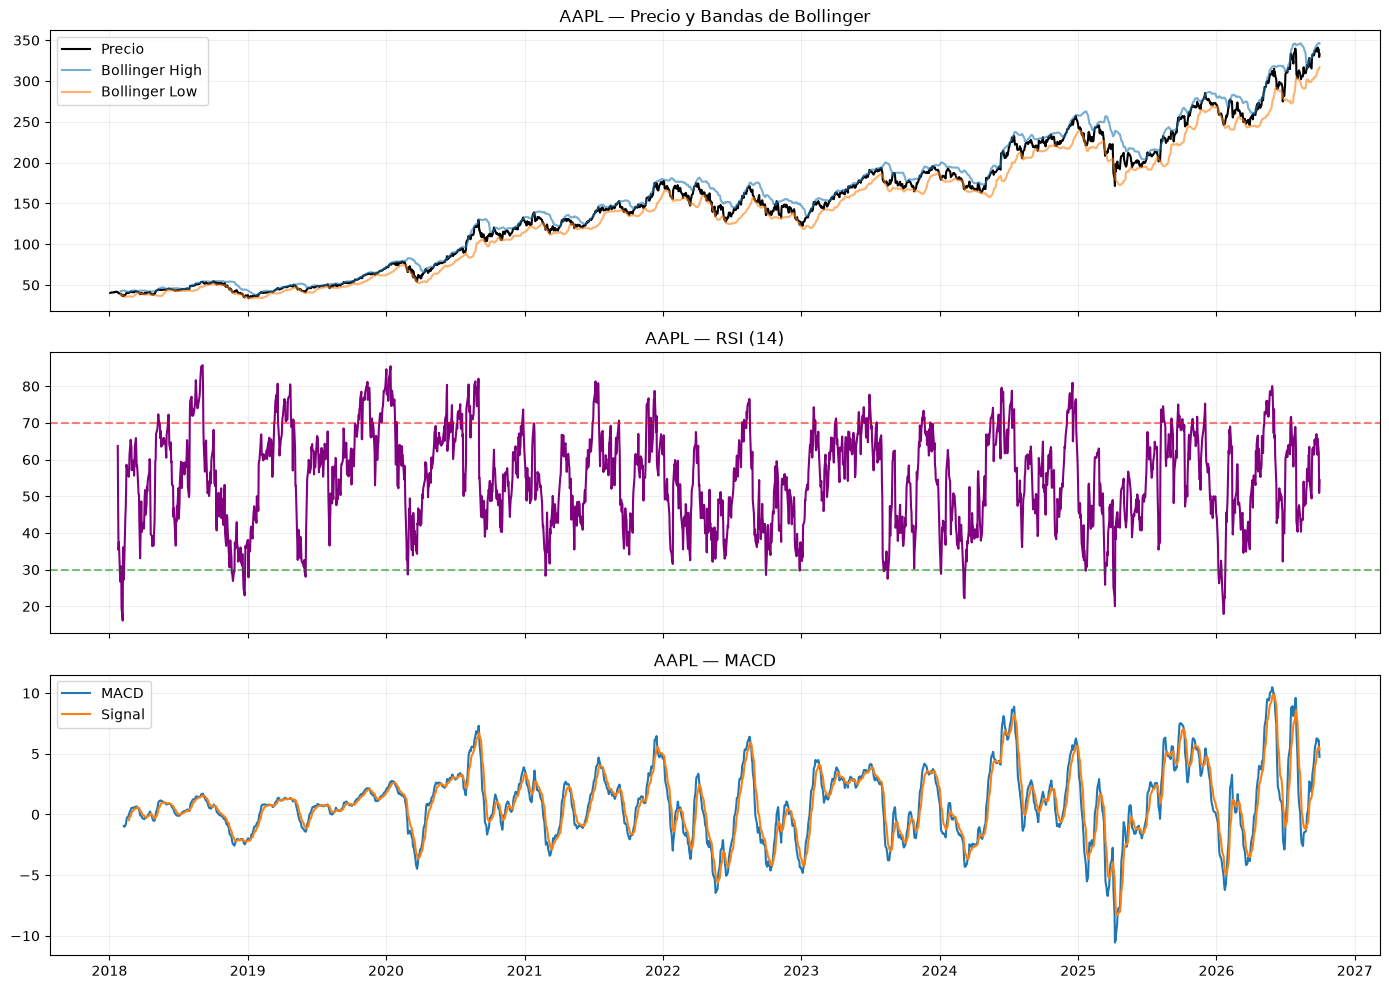

In [7]:
example_ticker = "AAPL"

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(prices_clean.index, prices_clean[example_ticker], label="Precio", color="black")
axes[0].plot(prices_clean.index, bb_high_features[example_ticker], label="Bollinger High", alpha=0.6)
axes[0].plot(prices_clean.index, bb_low_features[example_ticker], label="Bollinger Low", alpha=0.6)
axes[0].set_title(f"{example_ticker} — Precio y Bandas de Bollinger")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(prices_clean.index, rsi_features[example_ticker], color="purple")
axes[1].axhline(70, linestyle="--", color="red", alpha=0.5)
axes[1].axhline(30, linestyle="--", color="green", alpha=0.5)
axes[1].set_title(f"{example_ticker} — RSI (14)")
axes[1].grid(alpha=0.2)

axes[2].plot(prices_clean.index, macd_features[example_ticker], label="MACD")
axes[2].plot(prices_clean.index, macd_signal_features[example_ticker], label="Signal")
axes[2].set_title(f"{example_ticker} — MACD")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_indicadores_ejemplo.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Definición del target

Según el plan de trabajo (sección 9): predicción del retorno de los siguientes 5 días mediante ventana móvil. El `shift(-TARGET_HORIZON)` alinea cada fecha `t` con el retorno que ocurrirá entre `t` y `t + TARGET_HORIZON`, evitando que el modelo mire hacia atrás.

In [8]:
TARGET_HORIZON = 5

target = prices_clean.pct_change(TARGET_HORIZON).shift(-TARGET_HORIZON)

target.tail()


,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Construcción del panel largo (long format)

Se arma un solo DataFrame con columnas `Date`, `ticker`, cada feature y `target`, apilando todos los activos. Este formato es el más práctico para alimentar después a SVR/LSTM por activo o de forma conjunta.

In [9]:
panels = []

for ticker in prices_clean.columns:

    df_ticker = pd.DataFrame(index=prices_clean.index)

    df_ticker["ticker"] = ticker

    for name, frame in return_horizon_features.items():
        df_ticker[name] = frame[ticker]

    for name, frame in sma_features.items():
        df_ticker[name] = frame[ticker]

    for name, frame in ema_features.items():
        df_ticker[name] = frame[ticker]

    for name, frame in vol_features.items():
        df_ticker[name] = frame[ticker]

    df_ticker["rsi_14"] = rsi_features[ticker]
    df_ticker["macd"] = macd_features[ticker]
    df_ticker["macd_signal"] = macd_signal_features[ticker]
    df_ticker["bb_high"] = bb_high_features[ticker]
    df_ticker["bb_low"] = bb_low_features[ticker]

    df_ticker["target_return_5d"] = target[ticker]

    panels.append(df_ticker)

dataset = pd.concat(panels)
dataset.index.name = "Date"
dataset = dataset.reset_index()

print("Dataset shape (antes de limpiar NaN):", dataset.shape)
dataset.head()

sector_map = pd.read_csv(SECTOR_MAP_FILE)
dataset = dataset.merge(sector_map, on="ticker", how="left")
dataset["sector"] = dataset["sector"].fillna("Benchmark")

dataset.head()


Dataset shape (antes de limpiar NaN): (98865, 22)


,Date,ticker,return_5d,return_10d,return_21d,return_63d,return_1d,sma_10,sma_20,sma_50,...,vol_10,vol_20,vol_50,rsi_14,macd,macd_signal,bb_high,bb_low,target_return_5d,sector
0,2018-01-03,AAPL,NaN,NaN,NaN,NaN,-0.000174,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011960,Tecnología
1,2018-01-04,AAPL,NaN,NaN,NaN,NaN,0.004645,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013003,Tecnología
2,2018-01-05,AAPL,NaN,NaN,NaN,NaN,0.011385,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011942,Tecnología
3,2018-01-08,AAPL,NaN,NaN,NaN,NaN,-0.003714,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010554,Tecnología
4,2018-01-09,AAPL,NaN,NaN,NaN,NaN,-0.000115,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027362,Tecnología


## 6. Limpieza de NaN (leakage y ventanas)

Las ventanas móviles generan NaN al inicio de cada serie, y el `shift` del target genera NaN al final. Se descartan esas filas mas no se rellenan, para no introducir información artificial.

In [10]:
dataset_clean = dataset.dropna().reset_index(drop=True)

print("Dataset shape (después de limpiar NaN):", dataset_clean.shape)
print("Filas descartadas:", dataset.shape[0] - dataset_clean.shape[0])

dataset_clean.describe().T


Dataset shape (después de limpiar NaN): (95805, 23)
Filas descartadas: 3060


,count,mean,min,25%,50%,75%,max,std
Date,95805,2022-06-27 10:17:31.761390,2018-04-05 00:00:00,2020-05-15 00:00:00,2022-06-27 00:00:00,2024-08-08 00:00:00,2026-09-23 00:00:00,NaN
return_5d,95805.0,0.00377,-0.557438,-0.017285,0.003973,0.024413,0.564756,0.042949
return_10d,95805.0,0.007487,-0.636246,-0.022866,0.007749,0.037374,0.749405,0.059872
return_21d,95805.0,0.01566,-0.677229,-0.030711,0.014706,0.058908,1.087066,0.087181
return_63d,95805.0,0.04603,-0.692024,-0.038967,0.037533,0.117396,1.857399,0.149952
return_1d,95805.0,0.000758,-0.351166,-0.008025,0.000801,0.009534,0.278694,0.019823
sma_10,95805.0,269.642157,3.273734,69.46417,138.079193,231.430667,7748.729004,679.799527
sma_20,95805.0,268.900204,3.422968,69.16839,137.871391,231.262815,7716.864502,677.820726
sma_50,95805.0,266.657554,3.590761,68.54056,137.032759,229.30165,7629.258398,671.829693
ema_10,95805.0,269.64367,3.329469,69.409222,138.015816,231.501575,7718.364162,679.767259


## 7. Guardar el dataset final

In [11]:
OUTPUT_FILE = DATA_DIR / "features_dataset.csv"

dataset_clean.to_csv(OUTPUT_FILE, index=False)

print("Dataset guardado en:", OUTPUT_FILE)


Dataset guardado en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed_diversified\features_dataset.csv


## 8. Validación de las features

Antes de pasar a Markowitz/SVR/LSTM, conviene chequear que las variables construidas tengan rangos y distribuciones razonables, sobre todo los indicadores técnicos, que tienen rangos teóricos conocidos.

In [12]:
print("Estadísticas descriptivas de todas las features:\n")
dataset_clean.describe().T.round(4)


Estadísticas descriptivas de todas las features:



,count,mean,min,25%,50%,75%,max,std
Date,95805,2022-06-27 10:17:31.761390,2018-04-05 00:00:00,2020-05-15 00:00:00,2022-06-27 00:00:00,2024-08-08 00:00:00,2026-09-23 00:00:00,NaN
return_5d,95805.0,0.00377,-0.557438,-0.017285,0.003973,0.024413,0.564756,0.042949
return_10d,95805.0,0.007487,-0.636246,-0.022866,0.007749,0.037374,0.749405,0.059872
return_21d,95805.0,0.01566,-0.677229,-0.030711,0.014706,0.058908,1.087066,0.087181
return_63d,95805.0,0.04603,-0.692024,-0.038967,0.037533,0.117396,1.857399,0.149952
return_1d,95805.0,0.000758,-0.351166,-0.008025,0.000801,0.009534,0.278694,0.019823
sma_10,95805.0,269.642157,3.273734,69.46417,138.079193,231.430667,7748.729004,679.799527
sma_20,95805.0,268.900204,3.422968,69.16839,137.871391,231.262815,7716.864502,677.820726
sma_50,95805.0,266.657554,3.590761,68.54056,137.032759,229.30165,7629.258398,671.829693
ema_10,95805.0,269.64367,3.329469,69.409222,138.015816,231.501575,7718.364162,679.767259


### Chequeo de rangos esperados

- RSI debe estar acotado entre 0 y 100.
- Bollinger High siempre debe ser mayor o igual que Bollinger Low.
- No debe haber valores infinitos ni NaN remanentes.

In [13]:
checks = {}

checks["RSI fuera de [0, 100]"] = (
    (dataset_clean["rsi_14"] < 0) | (dataset_clean["rsi_14"] > 100)
).sum()

checks["Bollinger High < Bollinger Low"] = (
    dataset_clean["bb_high"] < dataset_clean["bb_low"]
).sum()

checks["Valores infinitos"] = np.isinf(
    dataset_clean.select_dtypes(include=[np.number])
).sum().sum()

checks["NaN remanentes"] = dataset_clean.isna().sum().sum()

for check, n in checks.items():
    status = "OK" if n == 0 else f"REVISAR ({n} casos)"
    print(f"{check}: {status}")


RSI fuera de [0, 100]: OK
Bollinger High < Bollinger Low: OK
Valores infinitos: OK
NaN remanentes: OK


### Distribución visual de los indicadores técnicos

Histogramas de RSI, MACD y volatilidad (30 días equivalente vía `vol_20`) sobre todo el panel, para detectar valores extremos o distribuciones raras.

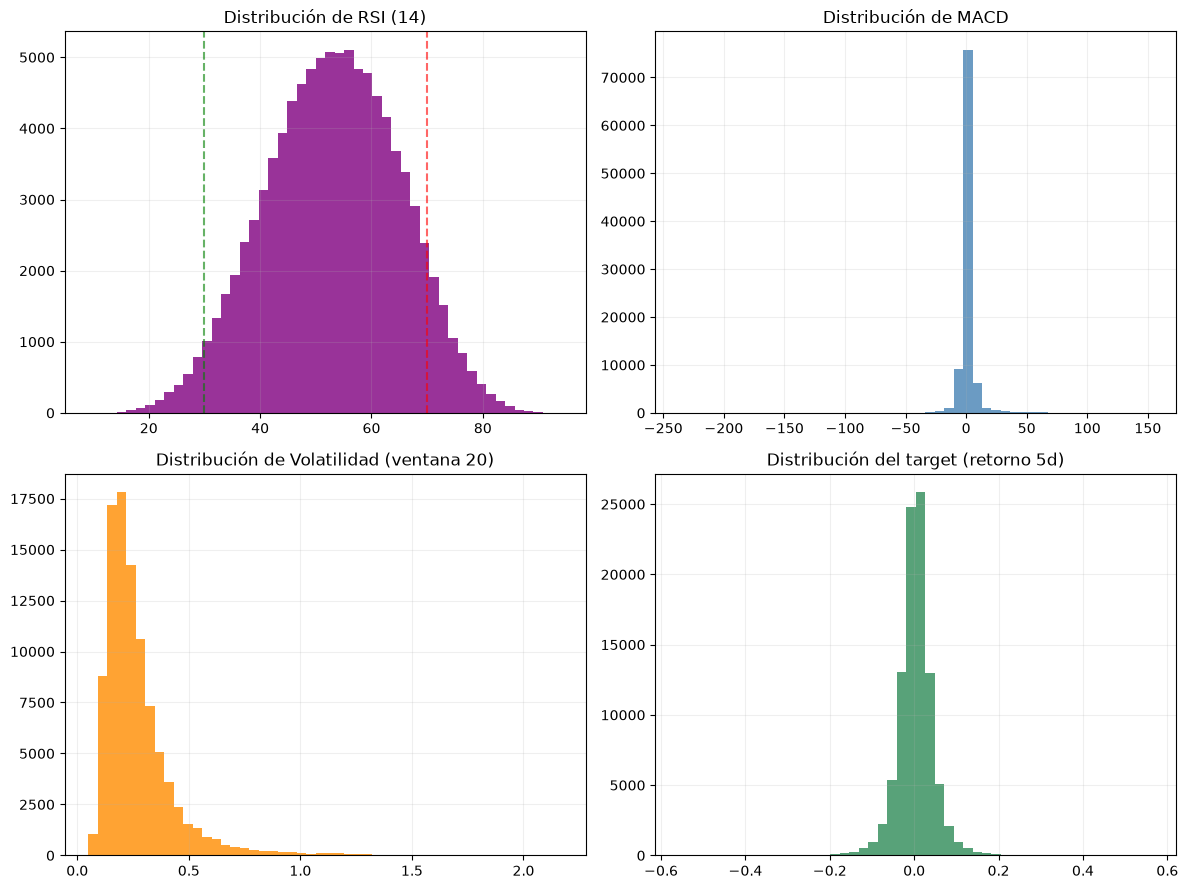

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(dataset_clean["rsi_14"], bins=50, color="purple", alpha=0.8)
axes[0, 0].set_title("Distribución de RSI (14)")
axes[0, 0].axvline(30, linestyle="--", color="green", alpha=0.6)
axes[0, 0].axvline(70, linestyle="--", color="red", alpha=0.6)
axes[0, 0].grid(alpha=0.2)

axes[0, 1].hist(dataset_clean["macd"], bins=50, color="steelblue", alpha=0.8)
axes[0, 1].set_title("Distribución de MACD")
axes[0, 1].grid(alpha=0.2)

axes[1, 0].hist(dataset_clean["vol_20"], bins=50, color="darkorange", alpha=0.8)
axes[1, 0].set_title("Distribución de Volatilidad (ventana 20)")
axes[1, 0].grid(alpha=0.2)

axes[1, 1].hist(dataset_clean["target_return_5d"], bins=50, color="seagreen", alpha=0.8)
axes[1, 1].set_title("Distribución del target (retorno 5d)")
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_validacion_distribuciones.png", dpi=300, bbox_inches="tight")
plt.show()


### Correlación de las features con el target

Una primera señal (no definitiva) de qué tan informativas son las variables: correlación lineal simple contra `target_return_5d`. No implica causalidad ni garantiza poder predictivo no lineal (para eso están SVR y LSTM), pero ayuda a detectar features rotas o completamente sin relación.

In [15]:
feature_cols = dataset_clean.select_dtypes(include=[np.number]).columns.drop("target_return_5d")

target_corr = dataset_clean[feature_cols].corrwith(
    dataset_clean["target_return_5d"]
).sort_values(ascending=False)

target_corr.round(4)


vol_50         0.0800
vol_20         0.0742
vol_10         0.0617
return_10d    -0.0066
sma_50        -0.0077
ema_50        -0.0078
bb_high       -0.0081
ema_20        -0.0083
sma_20        -0.0084
sma_10        -0.0085
ema_10        -0.0085
bb_low        -0.0087
return_1d     -0.0199
return_21d    -0.0223
macd          -0.0235
rsi_14        -0.0243
macd_signal   -0.0250
return_5d     -0.0276
return_63d    -0.0368
dtype: float64

### Correlación con el target, desglosada por sector

Chequeo adicional específico de este experimento: ¿las features técnicas son igual de (poco) informativas en todos los sectores, o hay sectores donde la señal es más fuerte? Por ejemplo, sectores más volátiles (Tecnología, Energía) podrían comportarse distinto a sectores defensivos (Servicios Públicos, Consumo Básico).

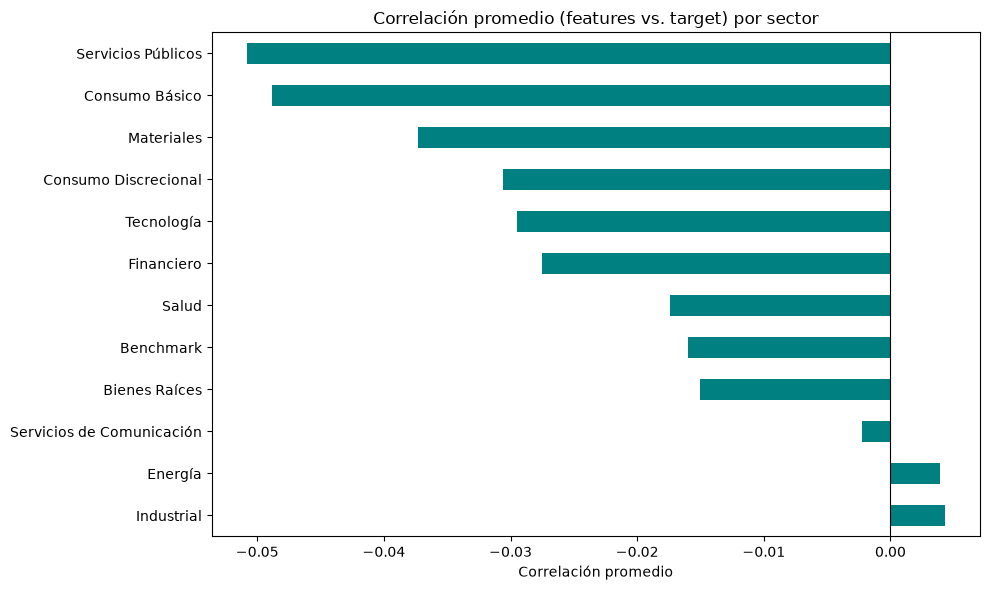

Industrial                   0.0043
Energía                      0.0039
Servicios de Comunicación   -0.0023
Bienes Raíces               -0.0150
Benchmark                   -0.0160
Salud                       -0.0174
Financiero                  -0.0275
Tecnología                  -0.0295
Consumo Discrecional        -0.0306
Materiales                  -0.0373
Consumo Básico              -0.0488
Servicios Públicos          -0.0508
Name: correlación promedio con el target, dtype: float64

In [16]:
sector_target_corr = {}

for sector in dataset_clean["sector"].unique():
    subset = dataset_clean[dataset_clean["sector"] == sector]
    corr_values = subset[feature_cols].corrwith(subset["target_return_5d"])
    sector_target_corr[sector] = corr_values.mean()

sector_target_corr = pd.Series(sector_target_corr, name="correlación promedio con el target").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sector_target_corr.plot(kind="barh", color="teal")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación promedio (features vs. target) por sector")
plt.xlabel("Correlación promedio")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_correlacion_por_sector.png", dpi=300, bbox_inches="tight")
plt.show()

sector_target_corr.round(4)
